In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
tickers=['NVDA','JNJ','PG','GC=F','CL=F','HG=F','BTC-USD','ETH-USD','SOL-USD']
irx = yf.Ticker("^IRX")
irx_data = irx.history(start="2021-01-01",end="2023-12-31")
eval_data=yf.download(tickers,start="2021-01-01",end="2023-12-31")['Close']
eval_data=eval_data.dropna()
returns=((eval_data-eval_data.shift(1))/eval_data.shift(1)).dropna()
percentage_returns=eval_data.pct_change().dropna()
log_returns=np.log(eval_data/eval_data.shift(1))
print("Assets loaded.Returns Matrix Shape:",returns.shape)

#Risk free rate calculation
rf_annual=irx_data['Close'].mean()/100
rf_daily=rf_annual/252
print(f"Daily risk free rate:{rf_daily:.6f}")
print(f"Annualized risk free rate:{rf_annual:.6f}")

C:\Users\sskan\AppData\Local\Temp\ipykernel_19272\893048297.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eval_data=yf.download(tickers,start="2021-01-01",end="2023-12-31")['Close']
[*********************100%***********************]  9 of 9 completed

Assets loaded.Returns Matrix Shape: (752, 9)
Daily risk free rate:0.000093
Annualized risk free rate:0.023519


In [3]:
print(returns.head())

Ticker       BTC-USD      CL=F   ETH-USD      GC=F      HG=F       JNJ  \
Date                                                                     
2021-01-05  0.063197  0.048509  0.057461  0.004114  0.024627  0.011757   
2021-01-06  0.083311  0.014020  0.097369 -0.023455  0.002610  0.009410   
2021-01-07  0.069157  0.003950  0.015380  0.002832  0.012466  0.003379   
2021-01-08  0.036234  0.027740 -0.001208 -0.040893 -0.005953 -0.002058   
2021-01-11 -0.128217  0.000191 -0.109502  0.008451 -0.029808 -0.004186   

Ticker          NVDA        PG   SOL-USD  
Date                                      
2021-01-05  0.022210  0.006385 -0.131938  
2021-01-06 -0.058953  0.010526 -0.105692  
2021-01-07  0.057830 -0.009347  0.229901  
2021-01-08 -0.005040 -0.000432  0.357030  
2021-01-11  0.025966 -0.006772 -0.034721  


In [4]:
#covariance matrix
cov_mat=(returns.cov())*252
print(cov_mat)


Ticker    BTC-USD      CL=F   ETH-USD      GC=F      HG=F       JNJ      NVDA  \
Ticker                                                                          
BTC-USD  0.414663  0.012243  0.426749  0.002754  0.026182  0.006977  0.114143   
CL=F     0.012243  0.156547  0.021727  0.010080  0.035941 -0.000965  0.006876   
ETH-USD  0.426749  0.021727  0.678922  0.006679  0.038081  0.013717  0.136774   
GC=F     0.002754  0.010080  0.006679  0.021019  0.013191  0.000363  0.004084   
HG=F     0.026182  0.035941  0.038081  0.013191  0.062999  0.000920  0.023320   
JNJ      0.006977 -0.000965  0.013717  0.000363  0.000920  0.026201  0.003975   
NVDA     0.114143  0.006876  0.136774  0.004084  0.023320  0.003975  0.280916   
PG       0.012642 -0.002735  0.019638  0.001098  0.001560  0.014158  0.012792   
SOL-USD  0.441981  0.019144  0.606318  0.002694  0.042854  0.010688  0.190472   

Ticker         PG   SOL-USD  
Ticker                       
BTC-USD  0.012642  0.441981  
CL=F    -0.002735 

In [5]:
#Expected returns annualised
annualized_returns=returns.mean()*252
annualized_returns

Ticker
BTC-USD    0.300463
CL=F       0.215834
ETH-USD    0.609415
GC=F       0.030206
HG=F       0.060969
JNJ        0.040625
NVDA       0.584653
PG         0.060715
SOL-USD    2.062007
dtype: float64

DATA VISUALIZED

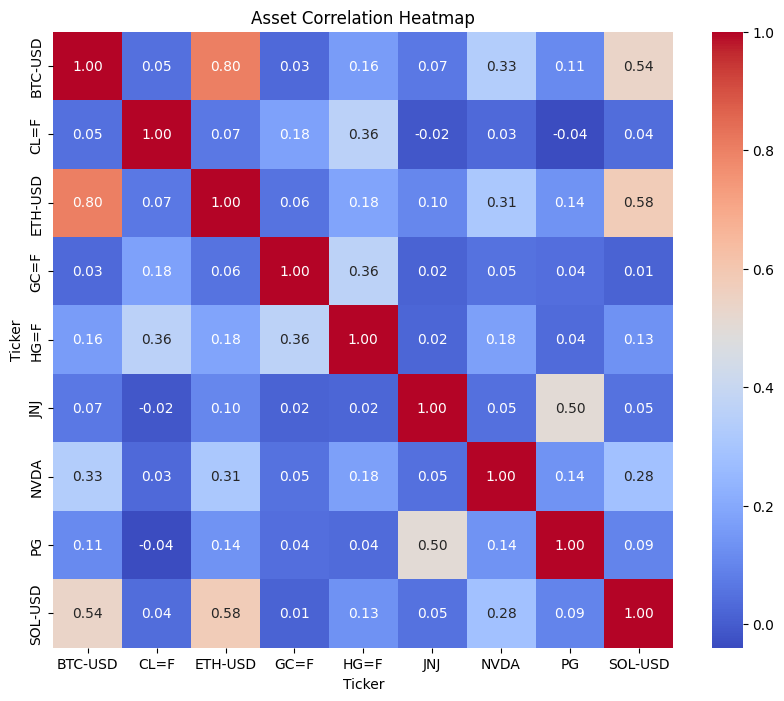

In [6]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Asset Correlation Heatmap')
plt.show()

FINANCIAL METRICS CALCULATION

In [7]:
#annualized volatility
annualized_volatility=np.sqrt(np.diag(cov_mat))
vol_series=pd.Series(annualized_volatility,index=cov_mat.index)
print(vol_series)

Ticker
BTC-USD    0.643943
CL=F       0.395660
ETH-USD    0.823967
GC=F       0.144980
HG=F       0.250996
JNJ        0.161867
NVDA       0.530015
PG         0.174225
SOL-USD    1.270162
dtype: float64


In [8]:
#sharpe ratio for individual assets
#risk free rate:we are taking us treasury bond as risk free rate
sharpe_ratio=(annualized_returns-rf_annual)/annualized_volatility
print(sharpe_ratio)

Ticker
BTC-USD    0.430076
CL=F       0.486060
ETH-USD    0.711067
GC=F       0.046126
HG=F       0.149206
JNJ        0.105681
NVDA       1.058713
PG         0.213494
SOL-USD    1.604904
dtype: float64


In [9]:
#Sortino Ratio
excess_daily=returns-rf_daily
downside_returns=excess_daily.copy()
downside_returns[downside_returns>0]=0
downside_std=np.sqrt((downside_returns**2).mean())*np.sqrt(252)
annual_excess=annualized_returns-rf_annual
sortino_ratio=annual_excess/downside_std
print(sortino_ratio)

Ticker
BTC-USD    0.621794
CL=F       0.664422
ETH-USD    1.028418
GC=F       0.063699
HG=F       0.214906
JNJ        0.152326
NVDA       1.668862
PG         0.294301
SOL-USD    2.630117
dtype: float64


In [10]:
#Maximum Drawdown
cumulative=(1+returns).cumprod()
running_max=cumulative.cummax()
drawdowns=(cumulative-running_max)/running_max
max_drawdown=drawdowns.min()
print(max_drawdown)

Ticker
BTC-USD   -0.766346
CL=F      -0.460469
ETH-USD   -0.784253
GC=F      -0.204304
HG=F      -0.348651
JNJ       -0.184117
NVDA      -0.663351
PG        -0.237725
SOL-USD   -0.961155
dtype: float64


In [11]:
#Calmar Ratios
excess_return=annualized_returns-rf_annual
max_pain=max_drawdown.abs()
calmar_ratio=excess_return/max_pain
print(calmar_ratio)


Ticker
BTC-USD    0.361383
CL=F       0.417650
ETH-USD    0.747074
GC=F       0.032732
HG=F       0.107414
JNJ        0.092910
NVDA       0.845908
PG         0.156467
SOL-USD    2.120874
dtype: float64


In [12]:
#VaR-Value at Risk
VaR_95=returns.quantile(0.05)
print(VaR_95)



Ticker
BTC-USD   -0.061281
CL=F      -0.040350
ETH-USD   -0.072786
GC=F      -0.015555
HG=F      -0.025850
JNJ       -0.015837
NVDA      -0.048931
PG        -0.017118
SOL-USD   -0.096684
Name: 0.05, dtype: float64


In [13]:
#CVaR-Conditional Value at Risk
CVaR_95=returns.apply(lambda x:x[x<=x.quantile(0.05)].mean())
print(CVaR_95)

Ticker
BTC-USD   -0.094462
CL=F      -0.058695
ETH-USD   -0.120548
GC=F      -0.021226
HG=F      -0.034041
JNJ       -0.022496
NVDA      -0.065380
PG        -0.025360
SOL-USD   -0.155773
dtype: float64


In [14]:
#skewness
skewness=returns.skew()
print(skewness)


Ticker
BTC-USD   -0.055828
CL=F      -0.520731
ETH-USD   -0.146148
GC=F      -0.273304
HG=F       0.134499
JNJ        0.266811
NVDA       0.707348
PG        -0.455989
SOL-USD    0.383704
dtype: float64


In [15]:
#kurtosis
kurtosis=returns.kurt()
print(kurtosis)

Ticker
BTC-USD    3.907570
CL=F       2.087092
ETH-USD    4.591947
GC=F       1.924029
HG=F       1.308731
JNJ        3.251702
NVDA       4.233723
PG         3.329414
SOL-USD    3.969982
dtype: float64


MONTE CARLO SIMULATION

In [ ]:
#weights generation
pre_weights=np.random.random((200000,9))
weights=pre_weights/np.sum(pre_weights,axis=1,keepdims=True)
portfolio_returns=weights@annualized_returns 
print(portfolio_returns)

[0.57674369 0.42420183 0.21900488 ... 0.35622491 0.29714558 0.48176177]


In [17]:
#portfolio volatility calculation
portfolio_volatilities=np.sqrt(np.sum((weights@cov_mat)*(weights),axis=1))
portfolio_volatilities

0         0.361602
1         0.314213
2         0.188348
3         0.371497
4         0.379769
            ...   
199995    0.246977
199996    0.499222
199997    0.338850
199998    0.231839
199999    0.342932
Length: 200000, dtype: float64

In [18]:
sharpe_ratios=(portfolio_returns-rf_annual)/portfolio_volatilities
max_sharpe_index=np.argmax(sharpe_ratios)
min_volatility_index=np.argmin(portfolio_volatilities)
max_sharpe_weights = weights[max_sharpe_index]
min_vol_weights = weights[min_volatility_index]

max_sharpe_val=sharpe_ratios[max_sharpe_index]
max_vol_at_max_sharpe=portfolio_volatilities[max_sharpe_index]
max_returns_at_max_sharpe=portfolio_returns[max_sharpe_index]

min_volatility_val=portfolio_volatilities[min_volatility_index]
min_sharpe_at_min_vol=sharpe_ratios[min_volatility_index]
min_returns_at_min_vol=portfolio_returns[min_volatility_index]

print(f"--- Max Sharpe Portfolio ---")
print(f"Sharpe Ratio: {max_sharpe_val:.4f}")
print(f"Volatility (Risk): {max_vol_at_max_sharpe:.4f}")
print(f"Return: {max_returns_at_max_sharpe:.4f}")
print(f"--- Max Sharpe Weights ---")
print(pd.Series(max_sharpe_weights,index=annualized_returns.index))

print(f"\n--- Min Volatility Portfolio ---")
print(f"Volatility (Risk): {min_volatility_val:.4f}")
print(f"Sharpe Ratio: {min_sharpe_at_min_vol:.4f}")
print(f"Return: {min_returns_at_min_vol:.4f}")
print("--- Min Volatility Weights ---")
print(pd.Series(min_vol_weights,index=annualized_returns.index))

--- Max Sharpe Portfolio ---
Sharpe Ratio: 1.7523
Volatility (Risk): 0.4938
Return: 0.8888
--- Max Sharpe Weights ---
Ticker
BTC-USD    0.002845
CL=F       0.279203
ETH-USD    0.000637
GC=F       0.001929
HG=F       0.092988
JNJ        0.004170
NVDA       0.292023
PG         0.010973
SOL-USD    0.315231
dtype: float64

--- Min Volatility Portfolio ---
Volatility (Risk): 0.1194
Sharpe Ratio: 0.7429
Return: 0.1122
--- Min Volatility Weights ---
Ticker
BTC-USD    0.005417
CL=F       0.083669
ETH-USD    0.026567
GC=F       0.300981
HG=F       0.144472
JNJ        0.137569
NVDA       0.042984
PG         0.252326
SOL-USD    0.006015
dtype: float64


In [ ]:
#Optimization
lowest_return=min_returns_at_min_vol - 0.05
highest_return=portfolio_returns.max()
target_returns=np.linspace(lowest_return,highest_return,150)
print(target_returns)

#risk calcculator->risk=variance=weight_matrix*covariance_matrix*portfolio_weights transpose 
def risk_calculator(portfolio_weights,cov):
    variance=portfolio_weights@cov@portfolio_weights
    return variance

#ensures sum of weights=1 cuz 100%
def weight_sum_constraint(weights):
    return weights.sum()-1
    
def return_constraint(weights,target_returns):
    return weights@annualized_returns-target_returns

#long only strat
from scipy.optimize import minimize

num_assets=len(annualized_returns)
initial_guess=np.ones(num_assets)/num_assets#initial assets are weighted equally
bounds=tuple((0,1) for _ in range(num_assets))#no shorting only long
R_t=target_returns[0]

constraints=[{'type':'eq','fun':weight_sum_constraint},{'type':'eq','fun':return_constraint,'args':(R_t,)}]
result=minimize(risk_calculator,initial_guess,args=(cov_mat,),method='SLSQP',bounds=bounds,constraints=constraints)

print("Success:",result.success)
print("Weights:",result.x)
print("Portfolio Return:",result.x@annualized_returns)
print("Portfolio variance:",result.fun)

[0.062219   0.07031939 0.07841977 0.08652016 0.09462055 0.10272093
 0.11082132 0.1189217  0.12702209 0.13512247 0.14322286 0.15132324
 0.15942363 0.16752402 0.1756244  0.18372479 0.19182517 0.19992556
 0.20802594 0.21612633 0.22422671 0.2323271  0.24042749 0.24852787
 0.25662826 0.26472864 0.27282903 0.28092941 0.2890298  0.29713018
 0.30523057 0.31333096 0.32143134 0.32953173 0.33763211 0.3457325
 0.35383288 0.36193327 0.37003365 0.37813404 0.38623443 0.39433481
 0.4024352  0.41053558 0.41863597 0.42673635 0.43483674 0.44293712
 0.45103751 0.45913789 0.46723828 0.47533867 0.48343905 0.49153944
 0.49963982 0.50774021 0.51584059 0.52394098 0.53204136 0.54014175
 0.54824214 0.55634252 0.56444291 0.57254329 0.58064368 0.58874406
 0.59684445 0.60494483 0.61304522 0.62114561 0.62924599 0.63734638
 0.64544676 0.65354715 0.66164753 0.66974792 0.6778483  0.68594869
 0.69404908 0.70214946 0.71024985 0.71835023 0.72645062 0.734551
 0.74265139 0.75075177 0.75885216 0.76695255 0.77505293 0.7831533

In [20]:
#Efficient frontier computation and optimization under constraints
#constraints-i)all capital must be invested ii)portfolio must achieve specific target sum with lowest variance iii)no short selling
frontier_volatility=[]
frontier_returns=[]

#optimizing multiple times
for R_t in target_returns:
    constraints=[
        {'type':'eq','fun':weight_sum_constraint},
        {'type':'eq','fun':return_constraint,'args':(R_t,)}
    ]
    result=minimize(risk_calculator,initial_guess,args=(cov_mat,),method='SLSQP',bounds=bounds,constraints=constraints)
    if result.success:
        frontier_volatility.append(np.sqrt(result.fun))
        frontier_returns.append(R_t)
        initial_guess=result.x

frontier_volatility=np.array(frontier_volatility)
frontier_returns=np.array(frontier_returns)
max_idx=np.argmax(frontier_returns)
frontier_returns=frontier_returns[:max_idx+1]
frontier_volatility=frontier_volatility[:max_idx+1]
print(frontier_returns)
print(frontier_volatility)

[0.062219   0.07031939 0.07841977 0.08652016 0.09462055 0.10272093
 0.11082132 0.1189217  0.12702209 0.13512247 0.14322286 0.15132324
 0.15942363 0.16752402 0.1756244  0.18372479 0.19182517 0.19992556
 0.20802594 0.21612633 0.22422671 0.2323271  0.24042749 0.24852787
 0.25662826 0.26472864 0.27282903 0.28092941 0.2890298  0.29713018
 0.30523057 0.31333096 0.32143134 0.32953173 0.33763211 0.3457325
 0.35383288 0.36193327 0.37003365 0.37813404 0.38623443 0.39433481
 0.4024352  0.41053558 0.41863597 0.42673635 0.43483674 0.44293712
 0.45103751 0.45913789 0.46723828 0.47533867 0.48343905 0.49153944
 0.49963982 0.50774021 0.51584059 0.52394098 0.53204136 0.54014175
 0.54824214 0.55634252 0.56444291 0.57254329 0.58064368 0.58874406
 0.59684445 0.60494483 0.61304522 0.62114561 0.62924599 0.63734638
 0.64544676 0.65354715 0.66164753 0.66974792 0.6778483  0.68594869
 0.69404908 0.70214946 0.71024985 0.71835023 0.72645062 0.734551
 0.74265139 0.75075177 0.75885216 0.76695255 0.77505293 0.7831533

In [21]:
#Capital Market Line
tangency_return=portfolio_returns[max_sharpe_index]
tangency_volatility=portfolio_volatilities[max_sharpe_index]
cml_slope=(tangency_return-rf_annual)/tangency_volatility
sigma_range=np.linspace(0,tangency_volatility*1.5,100)
cml_returns=rf_annual+cml_slope*sigma_range
print(cml_slope)
print(sigma_range)
print(cml_returns)

1.7523319165606244
[0.         0.00748172 0.01496344 0.02244516 0.02992688 0.0374086
 0.04489031 0.05237203 0.05985375 0.06733547 0.07481719 0.08229891
 0.08978063 0.09726235 0.10474407 0.11222579 0.11970751 0.12718923
 0.13467094 0.14215266 0.14963438 0.1571161  0.16459782 0.17207954
 0.17956126 0.18704298 0.1945247  0.20200642 0.20948814 0.21696986
 0.22445157 0.23193329 0.23941501 0.24689673 0.25437845 0.26186017
 0.26934189 0.27682361 0.28430533 0.29178705 0.29926877 0.30675049
 0.3142322  0.32171392 0.32919564 0.33667736 0.34415908 0.3516408
 0.35912252 0.36660424 0.37408596 0.38156768 0.3890494  0.39653111
 0.40401283 0.41149455 0.41897627 0.42645799 0.43393971 0.44142143
 0.44890315 0.45638487 0.46386659 0.47134831 0.47883003 0.48631174
 0.49379346 0.50127518 0.5087569  0.51623862 0.52372034 0.53120206
 0.53868378 0.5461655  0.55364722 0.56112894 0.56861066 0.57609237
 0.58357409 0.59105581 0.59853753 0.60601925 0.61350097 0.62098269
 0.62846441 0.63594613 0.64342785 0.65090957 

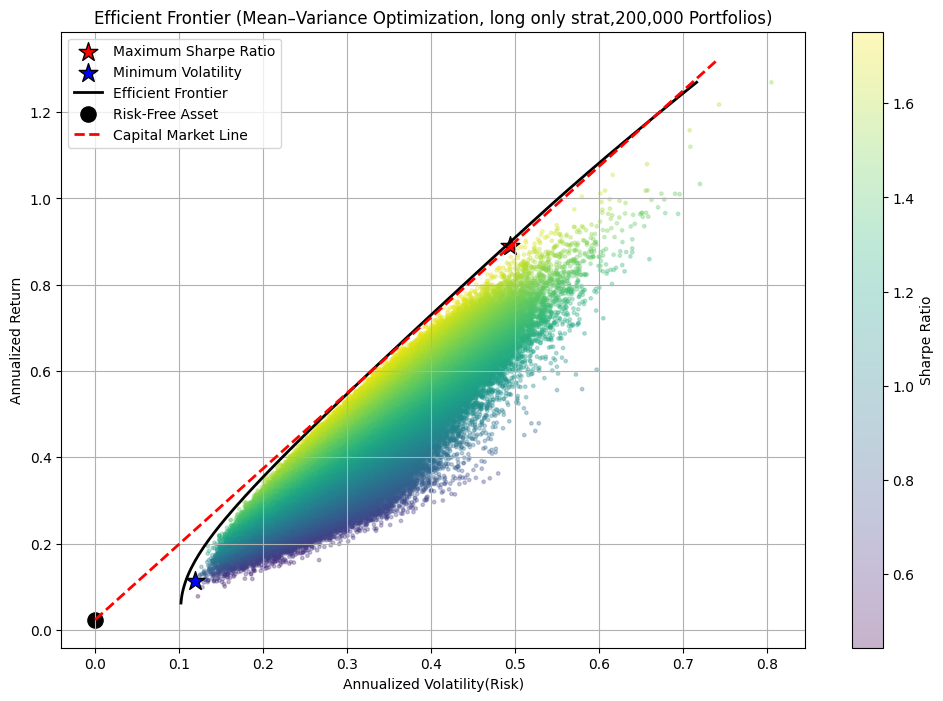

In [22]:
#Efficient Frontier
plt.figure(figsize=(12,8))

#Scatterplot of 200000 portfolios
plt.scatter(portfolio_volatilities,portfolio_returns,c=sharpe_ratios,cmap='viridis',marker='o',s=6,alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

#Max Sharpe Ratio Portfolio
plt.scatter(portfolio_volatilities[max_sharpe_index],portfolio_returns[max_sharpe_index],color='red',marker='*',s=200,label='Maximum Sharpe Ratio',edgecolor='black')
#Minimum Volatility Portfolio
plt.scatter(portfolio_volatilities[min_volatility_index],portfolio_returns[min_volatility_index],color='blue',marker='*',s=200,label='Minimum Volatility',edgecolor='black')

#Efficient Frontier Diagram
idx = np.argsort(frontier_volatility)
frontier_volatility = frontier_volatility[idx]
frontier_returns = frontier_returns[idx]
plt.plot(frontier_volatility, frontier_returns, color='black', linewidth=2, label='Efficient Frontier')
plt.scatter(0, rf_annual,color='black', marker='o', s=120,label='Risk-Free Asset')
plt.plot(sigma_range, cml_returns,linestyle='--', color='red', linewidth=2,label='Capital Market Line')
plt.title('Efficient Frontier (Mean–Variance Optimization, long only strat,200,000 Portfolios)')
plt.xlabel('Annualized Volatility(Risk)')
plt.ylabel('Annualized Return')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
#Metrics of portfolios

#Max Sharpe Portfolio
print("---PORTFOLIO METRICS---")
print("1.Tangency Portfolio(Max Sharpe)")
print("Return=",round(portfolio_returns[max_sharpe_index],2))
print("Volatility=",round(portfolio_volatilities[max_sharpe_index],2))
print("Sharpe Ratio=",round(sharpe_ratios[max_sharpe_index],2))
tangency_weights=weights[max_sharpe_index]
for asset,weight in zip(tickers,tangency_weights):
    print(asset,round(weight,4))
print()

#Min Volatility Portfolio
print("2.Minimum Volatility Portfolio")
print("Return=",round(portfolio_returns[min_volatility_index],2))
print("Volatility=",round(portfolio_volatilities[min_volatility_index],2))
print("Sharpe Ratio=",round(sharpe_ratios[min_volatility_index],2))
min_vol_weights=weights[min_volatility_index]
for asset,weight in zip(tickers,min_vol_weights):
    print(asset,round(weight,4))
print()

---PORTFOLIO METRICS---
1.Tangency Portfolio(Max Sharpe)
Return= 0.89
Volatility= 0.49
Sharpe Ratio= 1.75
NVDA 0.0028
JNJ 0.2792
PG 0.0006
GC=F 0.0019
CL=F 0.093
HG=F 0.0042
BTC-USD 0.292
ETH-USD 0.011
SOL-USD 0.3152

2.Minimum Volatility Portfolio
Return= 0.11
Volatility= 0.12
Sharpe Ratio= 0.74
NVDA 0.0054
JNJ 0.0837
PG 0.0266
GC=F 0.301
CL=F 0.1445
HG=F 0.1376
BTC-USD 0.043
ETH-USD 0.2523
SOL-USD 0.006



In [ ]:
#weights generation
weights_2=np.random.randn(200000, num_assets)
weights_2=np.clip(weights_2,-0.5,0.5)
weights_2=weights_2 / np.sum(np.abs(weights_2), axis=1, keepdims=True)
mask = np.all((weights_2 >= -0.5) & (weights_2 <= 0.5), axis=1)
weights_2 = weights_2[mask]
portfolio_returns_2 = weights_2 @ annualized_returns

In [25]:
#portfolio volatility calculation
portfolio_volatilities_2=np.sqrt(np.sum((weights_2@cov_mat)*(weights_2),axis=1))
portfolio_volatilities_2

0         0.280075
1         0.227084
2         0.256757
3         0.228530
4         0.382186
            ...   
199995    0.218672
199996    0.221651
199997    0.161985
199998    0.292881
199999    0.195280
Length: 200000, dtype: float64

In [26]:
sharpe_ratios_2=(portfolio_returns_2-rf_annual)/portfolio_volatilities_2
max_sharpe_index_2=np.argmax(sharpe_ratios_2)
min_volatility_index_2=np.argmin(portfolio_volatilities_2)
max_sharpe_weights_2= weights_2[max_sharpe_index_2]
min_vol_weights_2= weights_2[min_volatility_index_2]

max_sharpe_val_2=sharpe_ratios_2[max_sharpe_index_2]
max_vol_at_max_sharpe_2=portfolio_volatilities_2[max_sharpe_index_2]
max_returns_at_max_sharpe_2=portfolio_returns_2[max_sharpe_index_2]

min_volatility_val_2=portfolio_volatilities_2[min_volatility_index_2]
min_sharpe_at_min_vol_2=sharpe_ratios_2[min_volatility_index_2]
min_returns_at_min_vol_2=portfolio_returns_2[min_volatility_index_2]

print(f"--- Max Sharpe Portfolio ---")
print(f"Sharpe Ratio: {max_sharpe_val_2:.4f}")
print(f"Volatility (Risk): {max_vol_at_max_sharpe_2:.4f}")
print(f"Return: {max_returns_at_max_sharpe_2:.4f}")
print(f"--- Max Sharpe Weights ---")
print(pd.Series(max_sharpe_weights_2,index=annualized_returns.index))

print(f"\n--- Min Volatility Portfolio ---")
print(f"Volatility (Risk): {min_volatility_val_2:.4f}")
print(f"Sharpe Ratio: {min_sharpe_at_min_vol_2:.4f}")
print(f"Return: {min_returns_at_min_vol_2:.4f}")
print("--- Min Volatility Weights ---")
print(pd.Series(min_vol_weights_2,index=annualized_returns.index))

--- Max Sharpe Portfolio ---
Sharpe Ratio: 1.8557
Volatility (Risk): 0.2455
Return: 0.4790
--- Max Sharpe Weights ---
Ticker
BTC-USD   -0.152167
CL=F       0.178216
ETH-USD    0.010095
GC=F       0.060817
HG=F      -0.036983
JNJ        0.178216
NVDA       0.178216
PG         0.027072
SOL-USD    0.178216
dtype: float64

--- Min Volatility Portfolio ---
Volatility (Risk): 0.0787
Sharpe Ratio: -0.1264
Return: 0.0136
--- Min Volatility Weights ---
Ticker
BTC-USD   -0.046885
CL=F      -0.112103
ETH-USD    0.040637
GC=F      -0.183442
HG=F       0.183442
JNJ       -0.183442
NVDA       0.080710
PG         0.155882
SOL-USD   -0.013457
dtype: float64


In [27]:
#long and short strat
#Efficient frontier computation and optimization under constraints
#constraints-i)all capital must be invested ii)portfolio must achieve specific target sum with lowest variance iii)shorting allowed
from scipy.optimize import minimize
frontier_volatility_2=[]
frontier_returns_2=[]
target_returns_2= np.linspace(min(annualized_returns), max(annualized_returns), 100)
bounds=tuple((-0.5,0.5)for _ in range(num_assets))#shorting allowed

initial_guess = np.ones(num_assets) / num_assets#equal weight portfolio
for R_t_2 in target_returns_2:
    constraints=[
        {'type':'eq','fun':weight_sum_constraint},
        {'type':'eq','fun':return_constraint,'args':(R_t_2,)}
    ]
    result=minimize(risk_calculator,initial_guess,args=(cov_mat,),method='SLSQP',bounds=bounds,constraints=constraints)    
    if not result.success:
        continue
    
    frontier_volatility_2.append(np.sqrt(result.fun))
    frontier_returns_2.append(result.x@annualized_returns)
    initial_guess=result.x

frontier_volatility_2=np.array(frontier_volatility_2)
frontier_returns_2=np.array(frontier_returns_2)
print("Success:",result.success)
print("Weights:",result.x)
print("Portfolio Return:",result.x@annualized_returns)
print("Portfolio variance:",result.fun)
print(frontier_returns_2)
print(frontier_volatility_2)

Success: False
Weights: [ 5.00000000e-01  5.00000000e-01  5.00000000e-01 -5.00000000e-01
 -1.15239618e-11 -5.00000000e-01  5.00000000e-01 -5.00000000e-01
  5.00000000e-01]
Portfolio Return: 1.8204123972843436
Portfolio variance: 1.7394975587147805
[0.03020616 0.0507294  0.07125264 0.09177588 0.11229912 0.13282235
 0.15334559 0.17386883 0.19439207 0.21491531 0.23543855 0.25596179
 0.27648503 0.29700827 0.31753151 0.33805474 0.35857798 0.37910122
 0.39962446 0.4201477  0.44067094 0.46119418 0.48171742 0.50224066
 0.5227639  0.54328714 0.56381037 0.58433361 0.60485685 0.62538009
 0.64590333 0.66642657 0.68694981 0.70747305 0.72799629 0.74851953
 0.76904276 0.789566   0.81008924 0.83061248 0.85113572 0.87165896
 0.8921822  0.91270544 0.93322868 0.95375192 0.97427516 0.99479839
 1.01532163 1.03584487 1.05636811 1.07689135 1.09741459 1.11793783
 1.13846107 1.15898431 1.17950755 1.20003078 1.22055402 1.24107726
 1.2616005  1.28212374 1.30264698 1.32317022 1.34369346 1.3642167
 1.38473994 1.40

In [28]:
#Capital Market Line
tangency_index=np.argmax((frontier_returns_2-rf_annual)/frontier_volatility_2)
tangency_return_2=frontier_returns_2[tangency_index]
tangency_volatility_2=frontier_volatility_2[tangency_index]
cml_slope_2=(tangency_return_2-rf_annual)/tangency_volatility_2
sigma_range_2=np.linspace(0,tangency_volatility_2*1.5,100)
cml_returns_2=rf_annual+cml_slope_2*sigma_range_2
print(cml_slope_2)
print(sigma_range_2)
print(cml_returns_2)

1.9246345429546512
[0.         0.00958512 0.01917024 0.02875536 0.03834048 0.0479256
 0.05751072 0.06709584 0.07668097 0.08626609 0.09585121 0.10543633
 0.11502145 0.12460657 0.13419169 0.14377681 0.15336193 0.16294705
 0.17253217 0.18211729 0.19170241 0.20128753 0.21087266 0.22045778
 0.2300429  0.23962802 0.24921314 0.25879826 0.26838338 0.2779685
 0.28755362 0.29713874 0.30672386 0.31630898 0.3258941  0.33547922
 0.34506435 0.35464947 0.36423459 0.37381971 0.38340483 0.39298995
 0.40257507 0.41216019 0.42174531 0.43133043 0.44091555 0.45050067
 0.46008579 0.46967091 0.47925604 0.48884116 0.49842628 0.5080114
 0.51759652 0.52718164 0.53676676 0.54635188 0.555937   0.56552212
 0.57510724 0.58469236 0.59427748 0.6038626  0.61344773 0.62303285
 0.63261797 0.64220309 0.65178821 0.66137333 0.67095845 0.68054357
 0.69012869 0.69971381 0.70929893 0.71888405 0.72846917 0.73805429
 0.74763942 0.75722454 0.76680966 0.77639478 0.7859799  0.79556502
 0.80515014 0.81473526 0.82432038 0.8339055  0

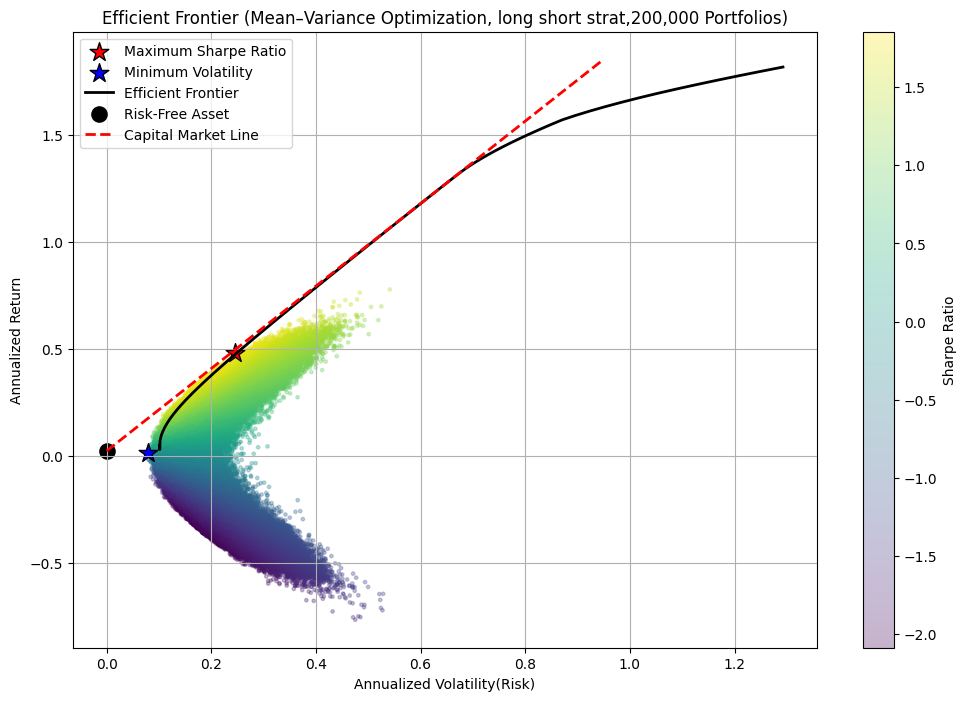

In [34]:
#Efficient Frontier
plt.figure(figsize=(12,8))

#Scatterplot of 200000 portfolios
plt.scatter(portfolio_volatilities_2,portfolio_returns_2,c=sharpe_ratios_2,cmap='viridis',marker='o',s=6,alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

#Max Sharpe Ratio Portfolio
plt.scatter(portfolio_volatilities_2[max_sharpe_index_2],portfolio_returns_2[max_sharpe_index_2],color='red',marker='*',s=200,label='Maximum Sharpe Ratio',edgecolor='black')
plt.scatter(portfolio_volatilities_2[min_volatility_index_2],portfolio_returns_2[min_volatility_index_2],color='blue',marker='*',s=200,label='Minimum Volatility',edgecolor='black')

#Efficient Frontier Diagram
idx=np.argsort(frontier_volatility_2)
frontier_volatility_2=frontier_volatility_2[idx]
frontier_returns_2=frontier_returns_2[idx]
min_idx=np.argmin(frontier_volatility_2)
frontier_volatility_2= frontier_volatility_2[min_idx:]
frontier_returns_2= frontier_returns_2[min_idx:]
plt.plot(frontier_volatility_2, frontier_returns_2,color='black',linewidth=2,label='Efficient Frontier')
plt.scatter(0, rf_annual,color='black', marker='o', s=120,label='Risk-Free Asset')
plt.plot(sigma_range_2, cml_returns_2,linestyle='--', color='red', linewidth=2,label='Capital Market Line')
plt.title('Efficient Frontier (Mean–Variance Optimization, long short strat,200,000 Portfolios)')
plt.xlabel('Annualized Volatility(Risk)')
plt.ylabel('Annualized Return')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
#Metrics of portfolios

#Max Sharpe Portfolio
print("---PORTFOLIO METRICS---")
print("1.Tangency Portfolio(Max Sharpe)")
print("Return=",round(portfolio_returns_2[max_sharpe_index_2],2))
print("Volatility=",round(portfolio_volatilities_2[max_sharpe_index_2],2))
print("Sharpe Ratio=",round(sharpe_ratios_2[max_sharpe_index_2],2))
tangency_weights=weights_2[max_sharpe_index_2]
for asset,weight in zip(tickers,tangency_weights):
    print(asset,round(weight,4))
print()

#Min Volatility Portfolio
print("2.Minimum Volatility Portfolio")
print("Return=",round(portfolio_returns_2[min_volatility_index_2],2))
print("Volatility=",round(portfolio_volatilities_2[min_volatility_index_2],2))
print("Sharpe Ratio=",round(sharpe_ratios_2[min_volatility_index_2],2))
min_vol_weights=weights_2[min_volatility_index_2]
for asset,weight in zip(tickers,min_vol_weights):
    print(asset,round(weight,4))
print()

---PORTFOLIO METRICS---
1.Tangency Portfolio(Max Sharpe)
Return= 0.48
Volatility= 0.25
Sharpe Ratio= 1.86
NVDA -0.1522
JNJ 0.1782
PG 0.0101
GC=F 0.0608
CL=F -0.037
HG=F 0.1782
BTC-USD 0.1782
ETH-USD 0.0271
SOL-USD 0.1782

2.Minimum Volatility Portfolio
Return= 0.01
Volatility= 0.08
Sharpe Ratio= -0.13
NVDA -0.0469
JNJ -0.1121
PG 0.0406
GC=F -0.1834
CL=F 0.1834
HG=F -0.1834
BTC-USD 0.0807
ETH-USD 0.1559
SOL-USD -0.0135



PORTFOLIO REBALANCING LOGIC & ROLLING OPTIMIZATION (Long only)

In [31]:
#Define parameters
test_returns=returns.loc["2024-01-01":"2026-01-01"]
lookback=252
rebalance=21

test_returns_bt=[]
test_dates_bt=[]
weights_history=[]

In [32]:
def optimize_portfolio(mu,cov):
    Num_Assets=len(mu)
    Initial_Guess=np.ones(Num_Assets)/Num_Assets
    bounds=tuple((0,1) for _ in range(Num_Assets))

    constraints=[{'type':'eq','fun':lambda w:np.sum(w)-1}]

    result=minimize(risk_calculator,Initial_Guess,args=(cov,),bounds=bounds,constraints=constraints)
    return result.x

In [33]:
for i in range(lookback,len(returns)-rebalance,rebalance):
    window=returns.iloc[i-lookback:i]
    mu=window.mean()*252
    cov=window.cov()*252
    test_weights=optimize_portfolio(mu,cov)
    future_returns=returns.iloc[i:i+rebalance]
    port_returns=future_returns@test_weights